In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 48.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=c00c91e8dc9e1c08d79cf4cb525e57d6df06086baca3e4036214b87a4d734236
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


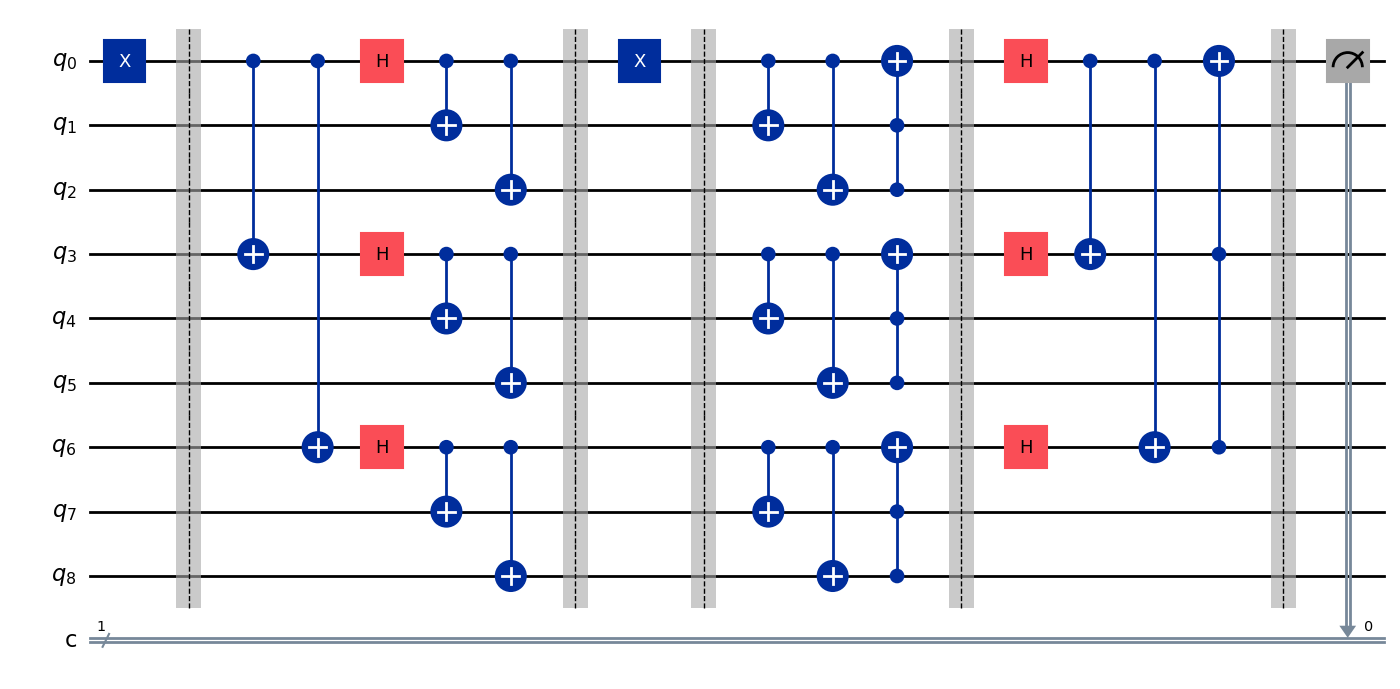

In [13]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.circuit import ControlledGate
from qiskit.circuit.classical import expr
import math

# Shor code

# Implement the Shor code and experiment with it, checking that it can correct bit-flip and phase-flip errors.
# You can also try applying some other unitary operator as an error, e.g. H.
# You can even construct a unitary operator from a function (as in Lab 3) and apply it as an error.
# You need more qubits now, so you will also have to change the simulation and measurement code in the next cell.

# Shor code
# Combines phase-flip code (outer) and bit-flip code (inner)
# Can correct ANY single qubit error: bit-flip, phase-flip, or both

# 17 qubits and 17 classical bits (was 5)
# qubits 0-8: 9 data qubits
# qubits 9-14: 6 syndrome qubits for bit-flip detection (2 per group of 3)
# qubits 15-16: 2 syndrome qubits for phase-flip detection
# classical bits mirror the qubits

shor = QuantumCircuit(9, 1)

shor.x(0)  # prepare |1>
shor.barrier()

# ---- ENCODING ----
shor.cx(0, 3)
shor.cx(0, 6)
shor.h(0); shor.h(3); shor.h(6)

shor.cx(0, 1); shor.cx(0, 2)
shor.cx(3, 4); shor.cx(3, 5)
shor.cx(6, 7); shor.cx(6, 8)

shor.barrier()

# ---- ERROR ----
shor.x(0)   # bit flip
# shor.z(0) # phase flip
# shor.h(0) # H error

shor.barrier()

# ---- BIT-FLIP CORRECTION (Toffoli per group) ----
shor.cx(0, 1); shor.cx(0, 2); shor.ccx(1, 2, 0)
shor.cx(3, 4); shor.cx(3, 5); shor.ccx(4, 5, 3)
shor.cx(6, 7); shor.cx(6, 8); shor.ccx(7, 8, 6)

shor.barrier()

# ---- PHASE-FLIP CORRECTION (Toffoli on group leaders) ----
shor.h(0); shor.h(3); shor.h(6)
shor.cx(0, 3); shor.cx(0, 6); shor.ccx(3, 6, 0)

shor.barrier()

# ---- MEASURE ----
shor.measure(0, 0)

shor.draw("mpl")

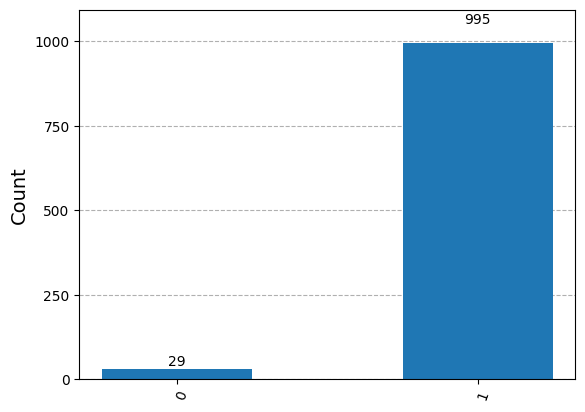

In [15]:
# Simulate and plot results
backend = GenericBackendV2(num_qubits=9, control_flow=True)
compiled = transpile(shor, backend)
job_sim = backend.run(compiled, shots=1024)
counts = job_sim.result().get_counts()
plot_histogram(counts)